In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits

plt.style.use("default")


# Principal Component Analysis (PCA)

In this notebook we:

1. Apply PCA to the **Seeds** dataset:
   - Explore and scale features
   - Project data onto principal components
   - Analyze explained variance

2. Apply PCA to the **Digits** dataset:
   - Visualize high-dimensional data in 2D
   - Examine how many components are needed
   - Use PCA for **denoising** images

---


In [3]:
# Load the Seeds dataset (ensure seeds.csv is in the same directory)
df = pd.read_csv("seeds.csv")

# Quick check
df.head()


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient,groove_length,species
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,0
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,0
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,0
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,0
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,0


In [4]:
display(df.describe())   # summary statistics
print("\nInfo:")
df.info()


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient,groove_length,species
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,1.000000
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,0.000000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,0.000000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,1.000000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,2.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,2.000000



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   area                   210 non-null    float64
 1   perimeter              210 non-null    float64
 2   compactness            210 non-null    float64
 3   kernel_length          210 non-null    float64
 4   kernel_width           210 non-null    float64
 5   asymmetry_coefficient  210 non-null    float64
 6   groove_length          210 non-null    float64
 7   species                210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


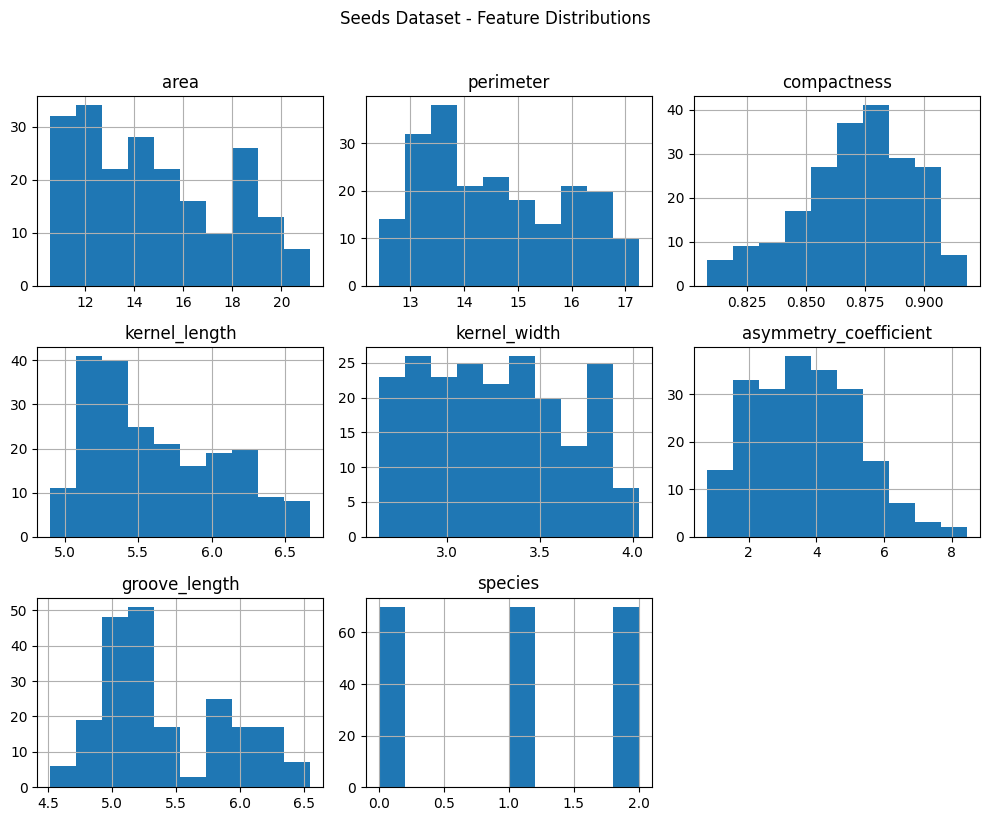

In [5]:
# Basic histograms for all numerical columns
df.hist(figsize=(10, 8))
plt.suptitle("Seeds Dataset - Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()


In [6]:
df.sample(10, random_state=42)


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient,groove_length,species
30,13.16,13.82,0.8662,5.454,2.975,0.8551,5.056,0
172,11.27,12.97,0.8419,5.088,2.763,4.3090,5.000,2
84,19.51,16.71,0.8780,6.366,3.801,2.9620,6.185,1
199,12.76,13.38,0.8964,5.073,3.155,2.8280,4.830,2
60,11.42,12.86,0.8683,5.008,2.850,2.7000,4.607,0
155,11.19,13.05,0.8253,5.250,2.675,5.8130,5.219,2
45,13.80,14.04,0.8794,5.376,3.155,1.5600,4.961,0
182,12.19,13.36,0.8579,5.240,2.909,4.8570,5.158,2
9,16.44,15.25,0.8880,5.884,3.505,1.9690,5.533,0
196,12.79,13.53,0.8786,5.224,3.054,5.4830,4.958,2


In [7]:
# Assume the first 7 columns are features and the last column is the class label
X = df.iloc[:, 0:7].values
y = df.iloc[:, 7].values   # species / class

# Scale features to [0, 1] range
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]


array([[0.44098206, 0.50206612, 0.5707804 , 0.48648649, 0.48610121,
        0.18930164, 0.34515017],
       [0.40509915, 0.44628099, 0.66243194, 0.36880631, 0.50106914,
        0.03288302, 0.21516494],
       [0.34938621, 0.34710744, 0.87931034, 0.22072072, 0.50392017,
        0.25145302, 0.1506647 ],
       [0.3068933 , 0.3161157 , 0.79310345, 0.2393018 , 0.53385602,
        0.19424255, 0.14081733],
       [0.52407932, 0.53305785, 0.86479129, 0.42736486, 0.66429081,
        0.07670104, 0.3229936 ]])

In [8]:
def plot_2d_scatter(data, labels, xlabel, ylabel, title):
    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(data[:, 0], data[:, 1], c=labels, cmap="viridis", alpha=0.8, edgecolors="k")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    handles, _ = scatter.legend_elements(prop="colors")
    unique_labels = np.unique(labels)
    if len(unique_labels) == len(handles):
        plt.legend(handles, unique_labels, title="Class", loc="best")
    plt.show()


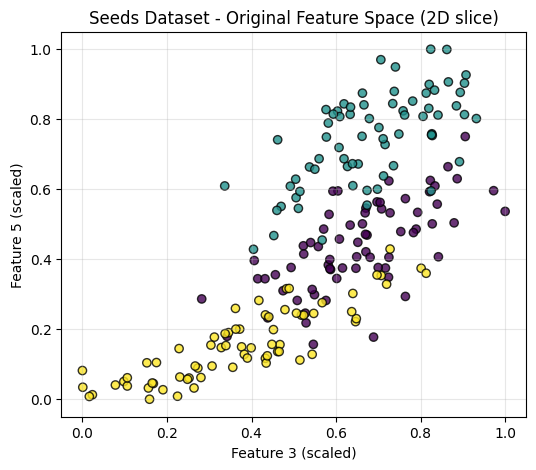

In [9]:
# Plot two original features just for comparison
feat_idx1, feat_idx2 = 2, 4  # choose any two dimensions
plt.figure(figsize=(6, 5))
plt.scatter(X_scaled[:, feat_idx1], X_scaled[:, feat_idx2], c=y, cmap="viridis", alpha=0.8, edgecolors="k")
plt.xlabel(f"Feature {feat_idx1 + 1} (scaled)")
plt.ylabel(f"Feature {feat_idx2 + 1} (scaled)")
plt.title("Seeds Dataset - Original Feature Space (2D slice)")
plt.grid(True, alpha=0.3)
plt.show()


Original shape: (210, 7)
PCA (2 components) shape: (210, 2)


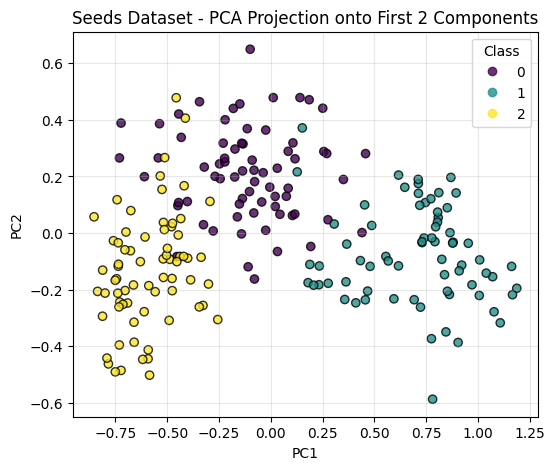

In [10]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("PCA (2 components) shape:", X_pca_2.shape)

plot_2d_scatter(
    X_pca_2, y,
    xlabel="PC1",
    ylabel="PC2",
    title="Seeds Dataset - PCA Projection onto First 2 Components"
)


Explained variance ratio per component:
PC1: 0.7890
PC2: 0.1291
PC3: 0.0687
PC4: 0.0094
PC5: 0.0027
PC6: 0.0009
PC7: 0.0001


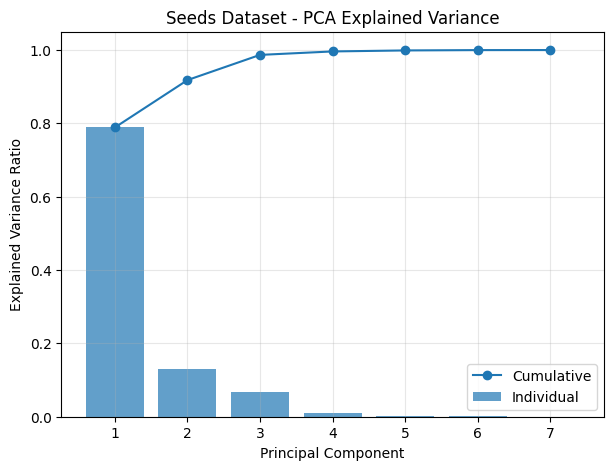

In [11]:
pca_full = PCA()
pca_full.fit(X_scaled)

evr = pca_full.explained_variance_ratio_
cumulative_evr = np.cumsum(evr)

print("Explained variance ratio per component:")
for i, v in enumerate(evr, start=1):
    print(f"PC{i}: {v:.4f}")

plt.figure(figsize=(7, 5))
plt.bar(range(1, len(evr) + 1), evr, alpha=0.7, label="Individual")
plt.plot(range(1, len(evr) + 1), cumulative_evr, marker="o", label="Cumulative")
plt.xticks(range(1, len(evr) + 1))
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Seeds Dataset - PCA Explained Variance")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### Interpretation (Seeds PCA)

- **PC1** captures the largest amount of variance in the scaled features.
- **PC2** adds additional variance while remaining orthogonal to PC1.
- The cumulative explained variance curve helps decide **how many components**
  we need to keep most of the information (e.g., 2–3 components may already
  capture a high percentage of the variance).

---


### Additional Notes on PCA for the Seeds Dataset

- Each **principal component** is a linear combination of the original features.  
- The coefficients of these combinations (called **loadings**) tell us which original features contribute most to each PC.  
- When classes separate visually in the PC1–PC2 plot, it indicates that PCA has captured structure that is useful for distinguishing classes, even though PCA itself is **unsupervised** (it does not use labels while computing components).  
- If only a small number of components explain most of the variance (e.g., 2–3), we can:
  - reduce dimensionality,
  - visualize data more easily,
  - and sometimes improve learning efficiency for later models.


In [12]:
digits = load_digits()
X_digits = digits.data        # shape: (n_samples, 64)
y_digits = digits.target      # digit labels (0-9)

X_digits.shape


(1797, 64)

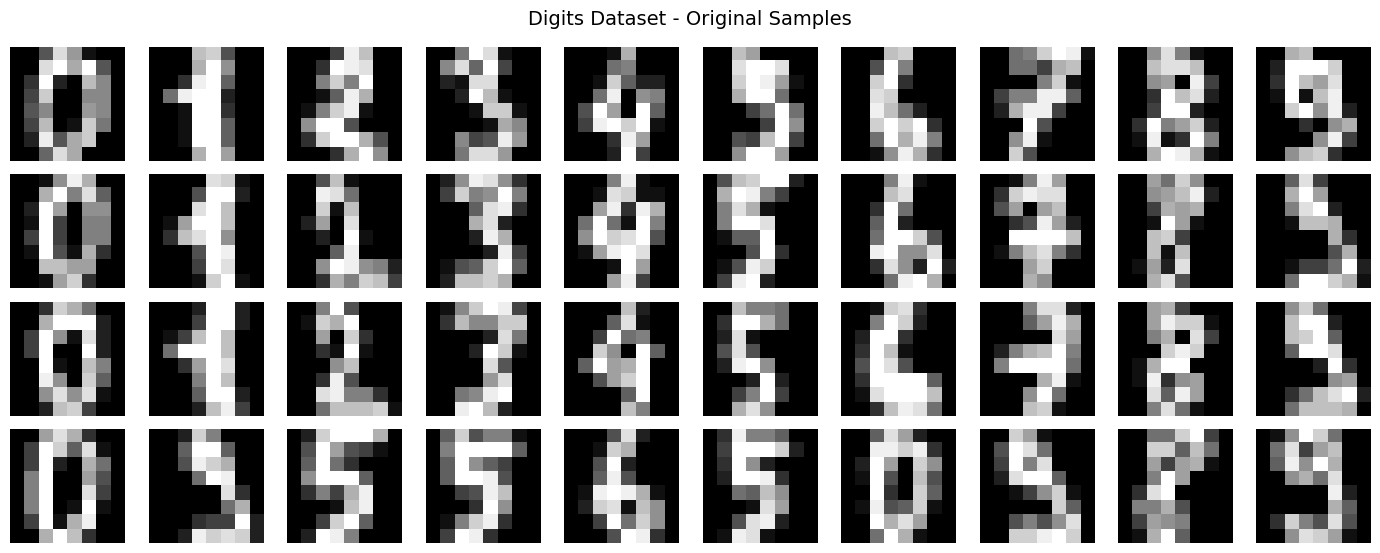

In [13]:
def plot_digits(data, n_rows=4, n_cols=10, title=None):
    """
    Display the first n_rows * n_cols digit images from `data`.
    Assumes each sample is 8x8 pixels.
    """
    num_images = n_rows * n_cols
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(1.4 * n_cols, 1.4 * n_rows),
                             subplot_kw={"xticks": [], "yticks": []})
    
    for i, ax in enumerate(axes.flat):
        if i < len(data):
            ax.imshow(data[i].reshape(8, 8), cmap="gray", interpolation="nearest")
        ax.axis("off")

    if title:
        fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_digits(X_digits, title="Digits Dataset - Original Samples")


In [14]:
pca_digits_2 = PCA(n_components=2)
X_digits_pca_2 = pca_digits_2.fit_transform(X_digits)

print("Original shape:", X_digits.shape)
print("PCA (2 components) shape:", X_digits_pca_2.shape)


Original shape: (1797, 64)
PCA (2 components) shape: (1797, 2)


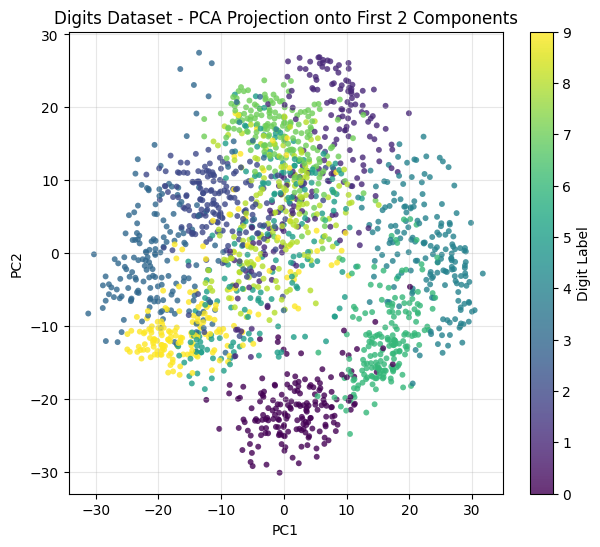

In [15]:
plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    X_digits_pca_2[:, 0],
    X_digits_pca_2[:, 1],
    c=y_digits,
    cmap="viridis",
    s=18,
    alpha=0.8,
    edgecolors="none"
)
plt.colorbar(scatter, label="Digit Label")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Digits Dataset - PCA Projection onto First 2 Components")
plt.grid(True, alpha=0.3)
plt.show()


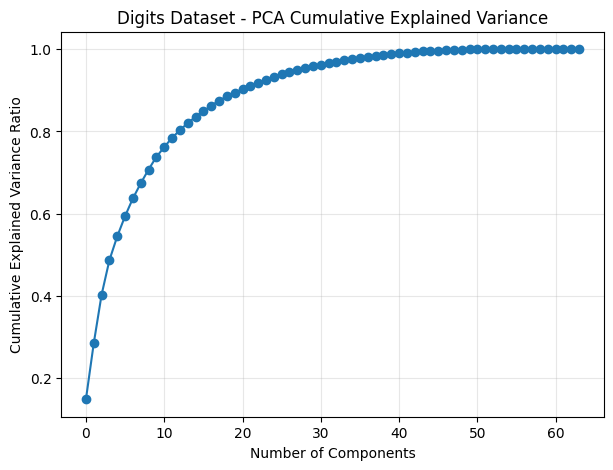

Components needed for >=90% variance: 21
Components needed for >=95% variance: 29


In [16]:
pca_digits_full = PCA()
pca_digits_full.fit(X_digits)

evr_digits = pca_digits_full.explained_variance_ratio_
cumulative_evr_digits = np.cumsum(evr_digits)

plt.figure(figsize=(7, 5))
plt.plot(cumulative_evr_digits, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.title("Digits Dataset - PCA Cumulative Explained Variance")
plt.grid(True, alpha=0.3)
plt.show()

components_90 = np.argmax(cumulative_evr_digits >= 0.90) + 1
components_95 = np.argmax(cumulative_evr_digits >= 0.95) + 1

print(f"Components needed for >=90% variance: {components_90}")
print(f"Components needed for >=95% variance: {components_95}")


### Interpretation (Digits PCA)

- High-dimensional 64-feature images can be well represented with
  far fewer principal components.
- The cumulative curve shows how quickly PCA captures variance.
- The 2D PCA plot organizes digits into meaningful clusters, even
  though we reduced from 64 dimensions to 2.

---


### Understanding PCA on Image Data

For the digits:

- Each image (8×8) is treated as a 64-dimensional vector.  
- PCA finds new axes that capture typical patterns in the images (e.g., general stroke shapes).  
- The first components often correspond to **broad, smooth structures**, while later components capture **fine details or noise**.  
- This is why PCA is useful for:
  - **Visualization**: mapping 64D images into 2D while still revealing clusters by digit.
  - **Compression**: representing images with fewer numbers.
  - **Denoising**: reconstructing images using only the most important components and discarding noisy ones.


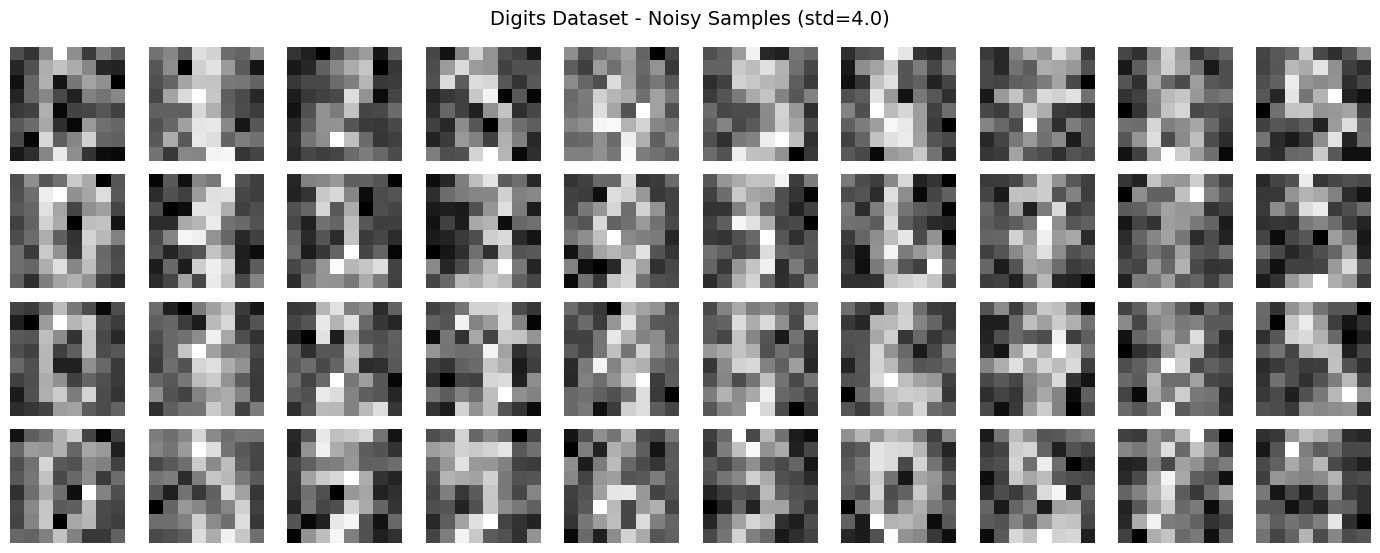

In [17]:
np.random.seed(42)
noise_std = 4.0

noisy_digits = X_digits + np.random.normal(loc=0.0, scale=noise_std, size=X_digits.shape)

plot_digits(noisy_digits, title=f"Digits Dataset - Noisy Samples (std={noise_std})")


In [18]:
pca_denoise = PCA(n_components=0.50)  # keep components that explain 50% of variance
pca_denoise.fit(noisy_digits)

print(f"Number of components used for denoising: {pca_denoise.n_components_}")

components = pca_denoise.transform(noisy_digits)
reconstructed = pca_denoise.inverse_transform(components)


Number of components used for denoising: 12


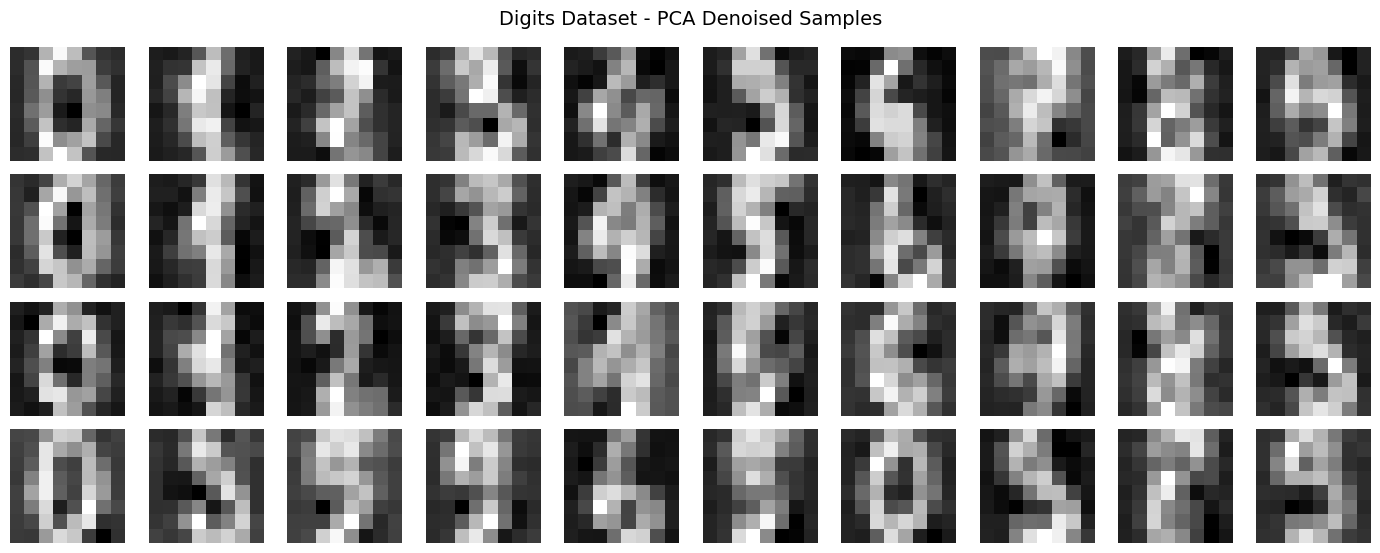

In [19]:
plot_digits(reconstructed, title="Digits Dataset - PCA Denoised Samples")


## Final Conclusion

1. **On the Seeds Dataset**
   - Scaling the features is essential so that attributes measured on different scales contribute fairly.  
   - PCA shows that a small number of principal components already explains a large proportion of the total variance.  
   - The 2D PCA projection separates classes reasonably well, which indicates that the main directions of variance are related to class differences.

2. **On the Digits Dataset**
   - High-dimensional image data (64 features) can be projected into just a few principal components while still preserving most of the structure.  
   - The 2D PCA plot does not perfectly separate digits but reveals meaningful clusters, confirming that PCA captures important visual patterns.  
   - Using PCA for denoising demonstrates a key idea: keeping only the dominant components preserves the main shape of each digit while filtering out random noise.

3. **Key Takeaways**
   - PCA is an **unsupervised** linear transformation that:
     - finds directions of maximum variance,
     - reduces dimensionality,
     - helps visualize complex data,
     - can improve efficiency and robustness of later models.  
   - It does **not** use class labels, so it is not a classifier by itself, but it often reveals structure that can help classification and interpretation.

This notebook illustrates PCA as both a **theoretical tool** (variance, components, projections) and a **practical tool** (visualization, compression, and denoising) on two different types of datasets.
